# Galaxy Redshift Prediction with Baseline Models


## 1. Setup

In [3]:
import os
import sys
import csv
import copy

project_root = os.path.abspath("../")
sys.path.insert(0, project_root)

import h5py
import numpy as np
import pandas as pd
import joblib
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import clear_output

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.metrics import make_scorer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

from src.data_loader import load_split, get_dataloaders, BAND_MEAN, BAND_STD
from src.metrics import redshift_metrics, evaluate_by_bin
from src.utils import (set_seed, get_device, SPLIT_COLORS,
                       save_checkpoint,
                       plot_pred_vs_true, plot_binned_performance)
from src.models.simple_cnn import GalaxiesMLCNN


%load_ext autoreload
%autoreload 2

GalaxiesMLCNN parameters: 1,206,817


In [4]:
set_seed(42)
device = get_device()

Using MPS (Apple Metal GPU)


## 2. Data


In [5]:
BASE_DATA = os.path.abspath("../data/")
BASE_MODELS = os.path.abspath("../models/")
BASE_REPORTS = os.path.abspath("../reports/")
os.makedirs(BASE_MODELS, exist_ok=True)

TRAIN_PATH = os.path.join(BASE_DATA, "5x127x127_training_with_morphology.hdf5")
VAL_PATH = os.path.join(BASE_DATA, "5x127x127_validation_with_morphology.hdf5")
TEST_PATH = os.path.join(BASE_DATA, "5x127x127_testing_with_morphology.hdf5")

EXCLUDE = {"image", "specz_redshift", "specz_redshift_err", "specz_flag_homogeneous"}

In [6]:
df_train = load_split(TRAIN_PATH)
df_val = load_split(VAL_PATH)
df_test = load_split(TEST_PATH)

print(f"\nSplit sizes:")
print(f"  Train : {len(df_train):>7,}  ×  {df_train.shape[1]-1} features")
print(f"  Val   : {len(df_val):>7,}  ×  {df_val.shape[1]-1} features")
print(f"  Test  : {len(df_test):>7,}  ×  {df_test.shape[1]-1} features")
print(f"\nRedshift range — "
      f"min: {df_train['specz_redshift'].min():.4f}, "
      f"max: {df_train['specz_redshift'].max():.4f}, "
      f"mean: {df_train['specz_redshift'].mean():.4f}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples, 89 features
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples, 89 features
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples, 89 features

Split sizes:
  Train : 204,573  ×  89 features
  Val   :  40,914  ×  89 features
  Test  :  40,914  ×  89 features

Redshift range — min: 0.0101, max: 3.9979, mean: 0.5950


## 3. Feature Analysis & Selection

In [7]:
feature_cols = [c for c in df_train.columns if c != "specz_redshift"]
numeric_cols = df_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

corr_with_label = (
    df_train[numeric_cols + ["specz_redshift"]]
    .corr()["specz_redshift"]
    .drop("specz_redshift")
    .abs()
    .sort_values(ascending=False)
)

print(f"Total numeric features: {len(numeric_cols)}")
print(f"\nTop 20 features most correlated with specz_redshift:")
print(corr_with_label.head(20).to_string())

Total numeric features: 87

Top 20 features most correlated with specz_redshift:
i_major_axis           0.577381
z_major_axis           0.564428
i_minor_axis           0.563103
r_major_axis           0.555023
y_half_light_radius    0.551215
y_major_axis           0.550371
z_minor_axis           0.549891
i_half_light_radius    0.549300
z_half_light_radius    0.547114
r_half_light_radius    0.546777
y_cmodel_mag           0.542015
r_minor_axis           0.540682
y_minor_axis           0.539531
z_cmodel_mag           0.536351
g_half_light_radius    0.535512
i_cmodel_mag           0.526626
i_isophotal_area       0.520295
specz_mag_i            0.514988
z_isophotal_area       0.505264
g_major_axis           0.504444


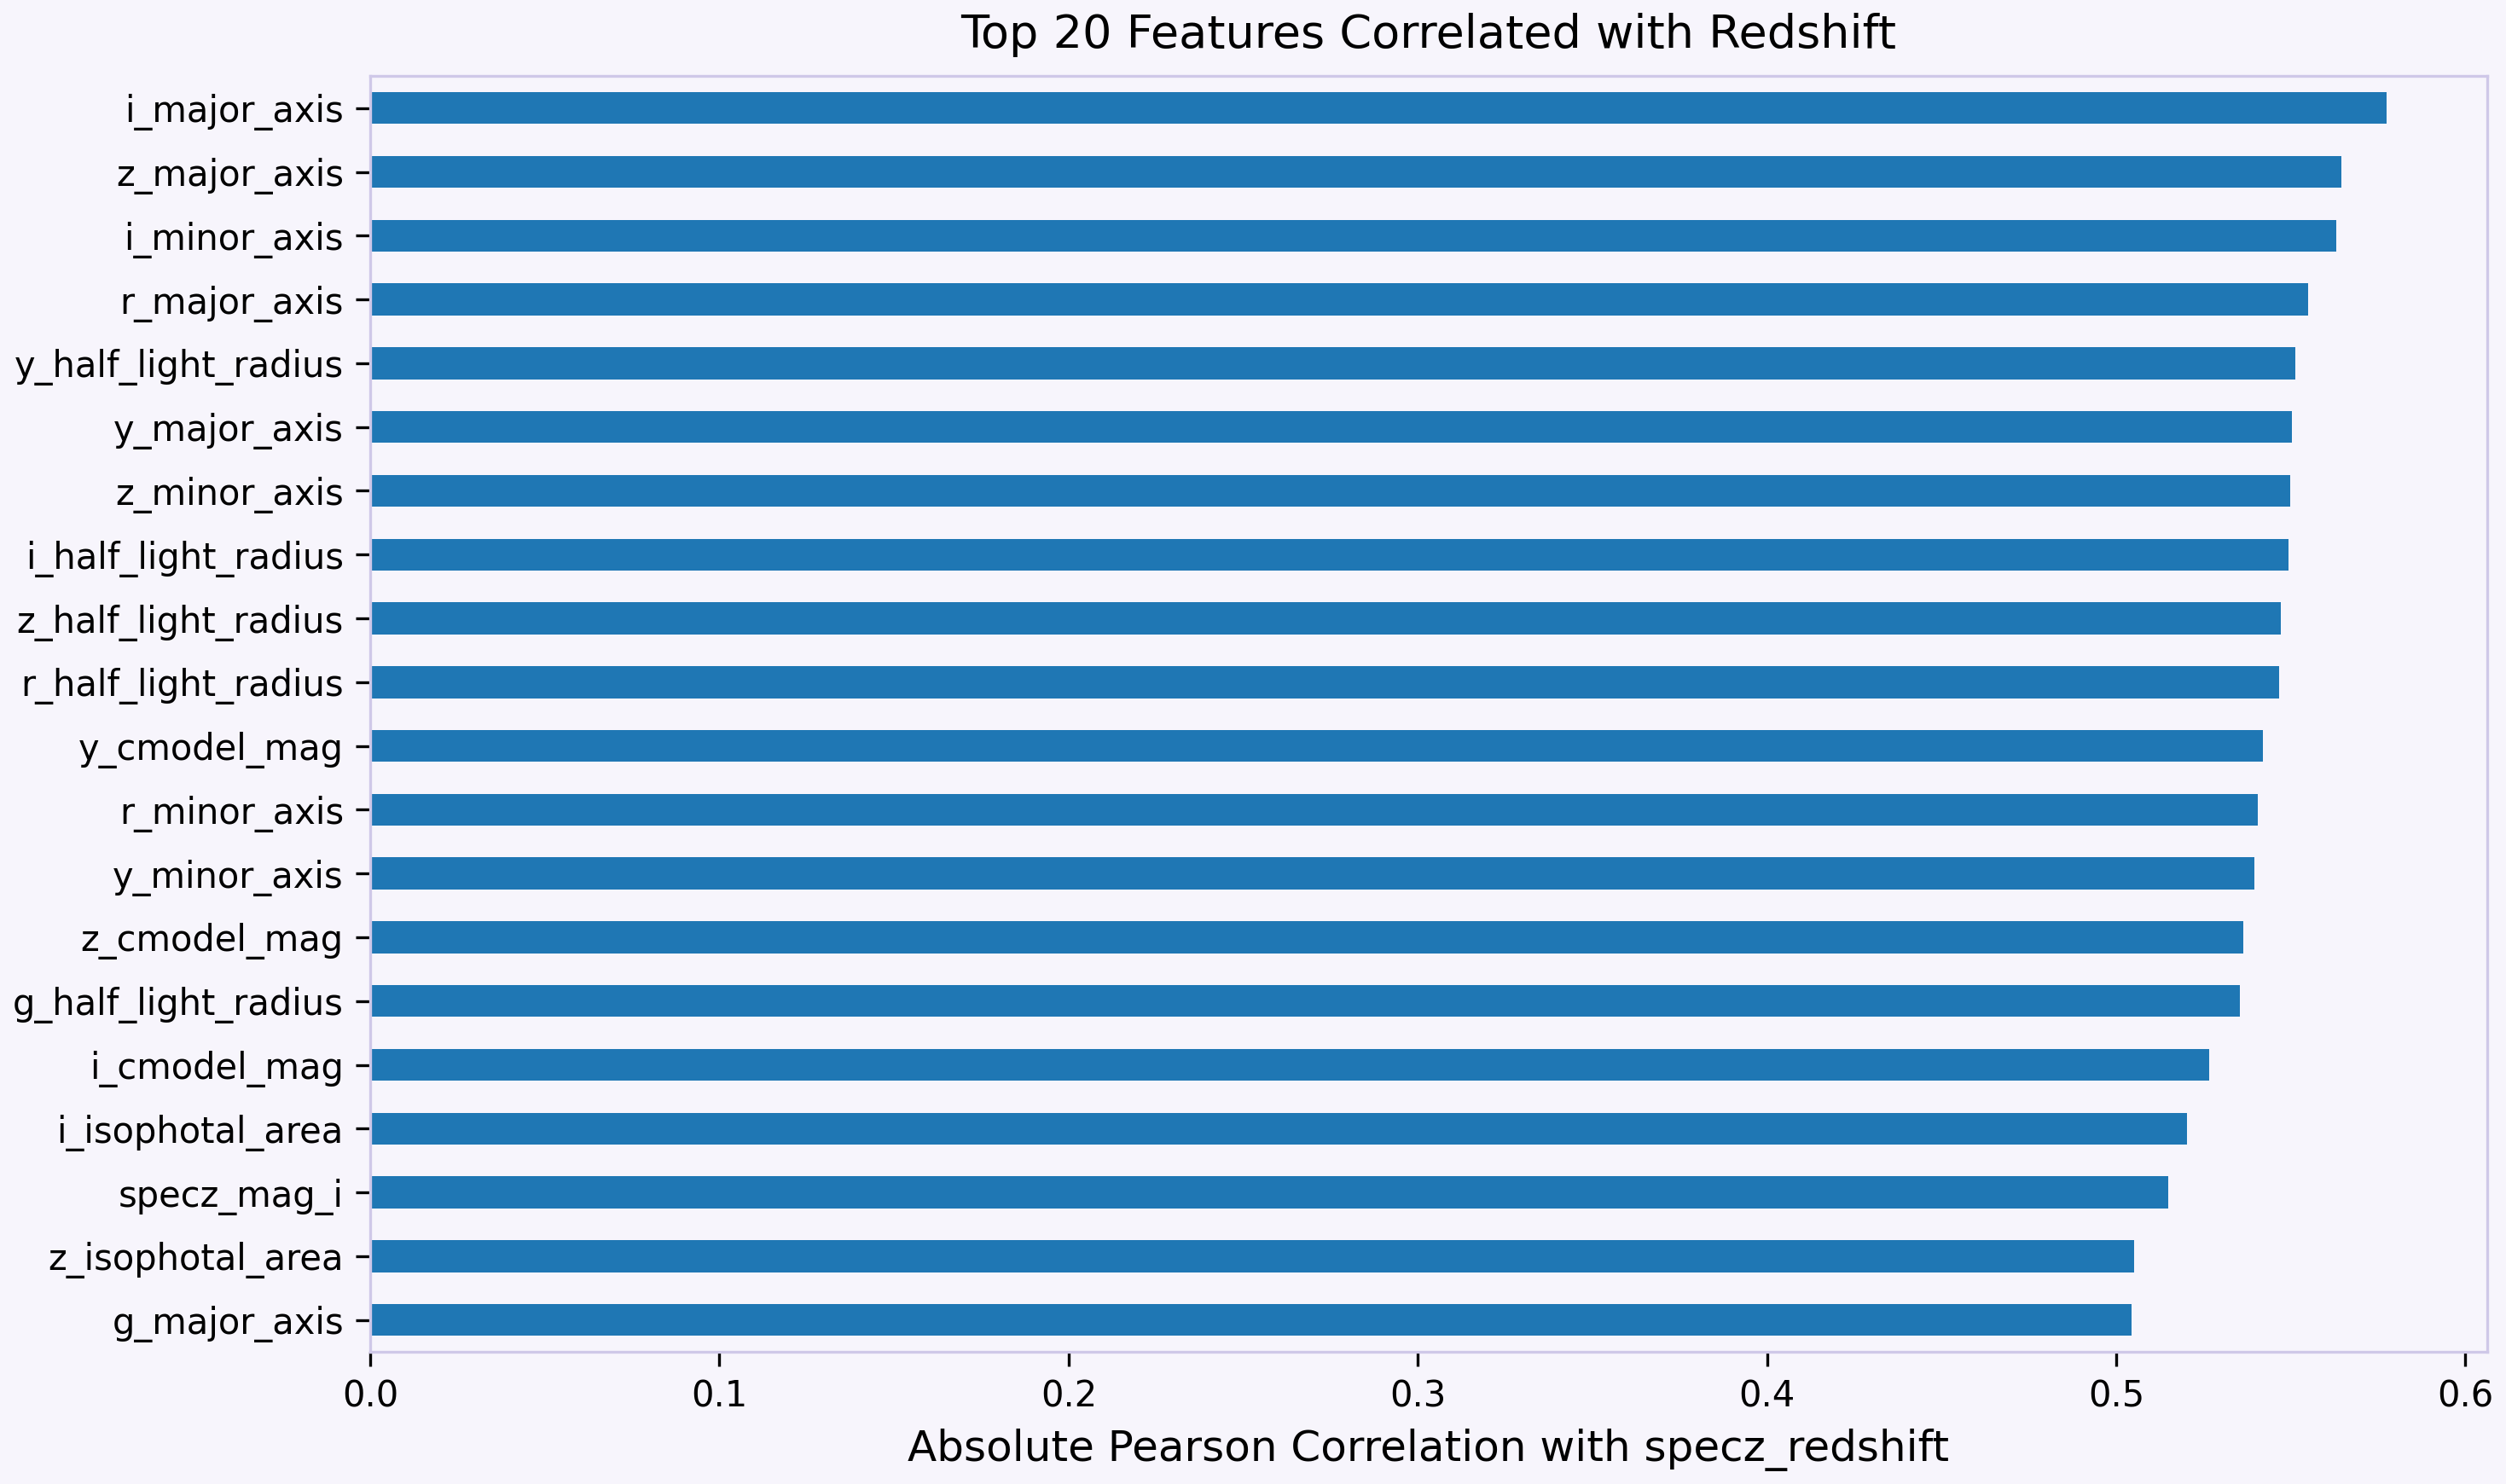

In [8]:
top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
corr_with_label.head(top_n).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Absolute Pearson Correlation with specz_redshift")
ax.set_title(f"Top {top_n} Features Correlated with Redshift")
plt.tight_layout()
plt.show()

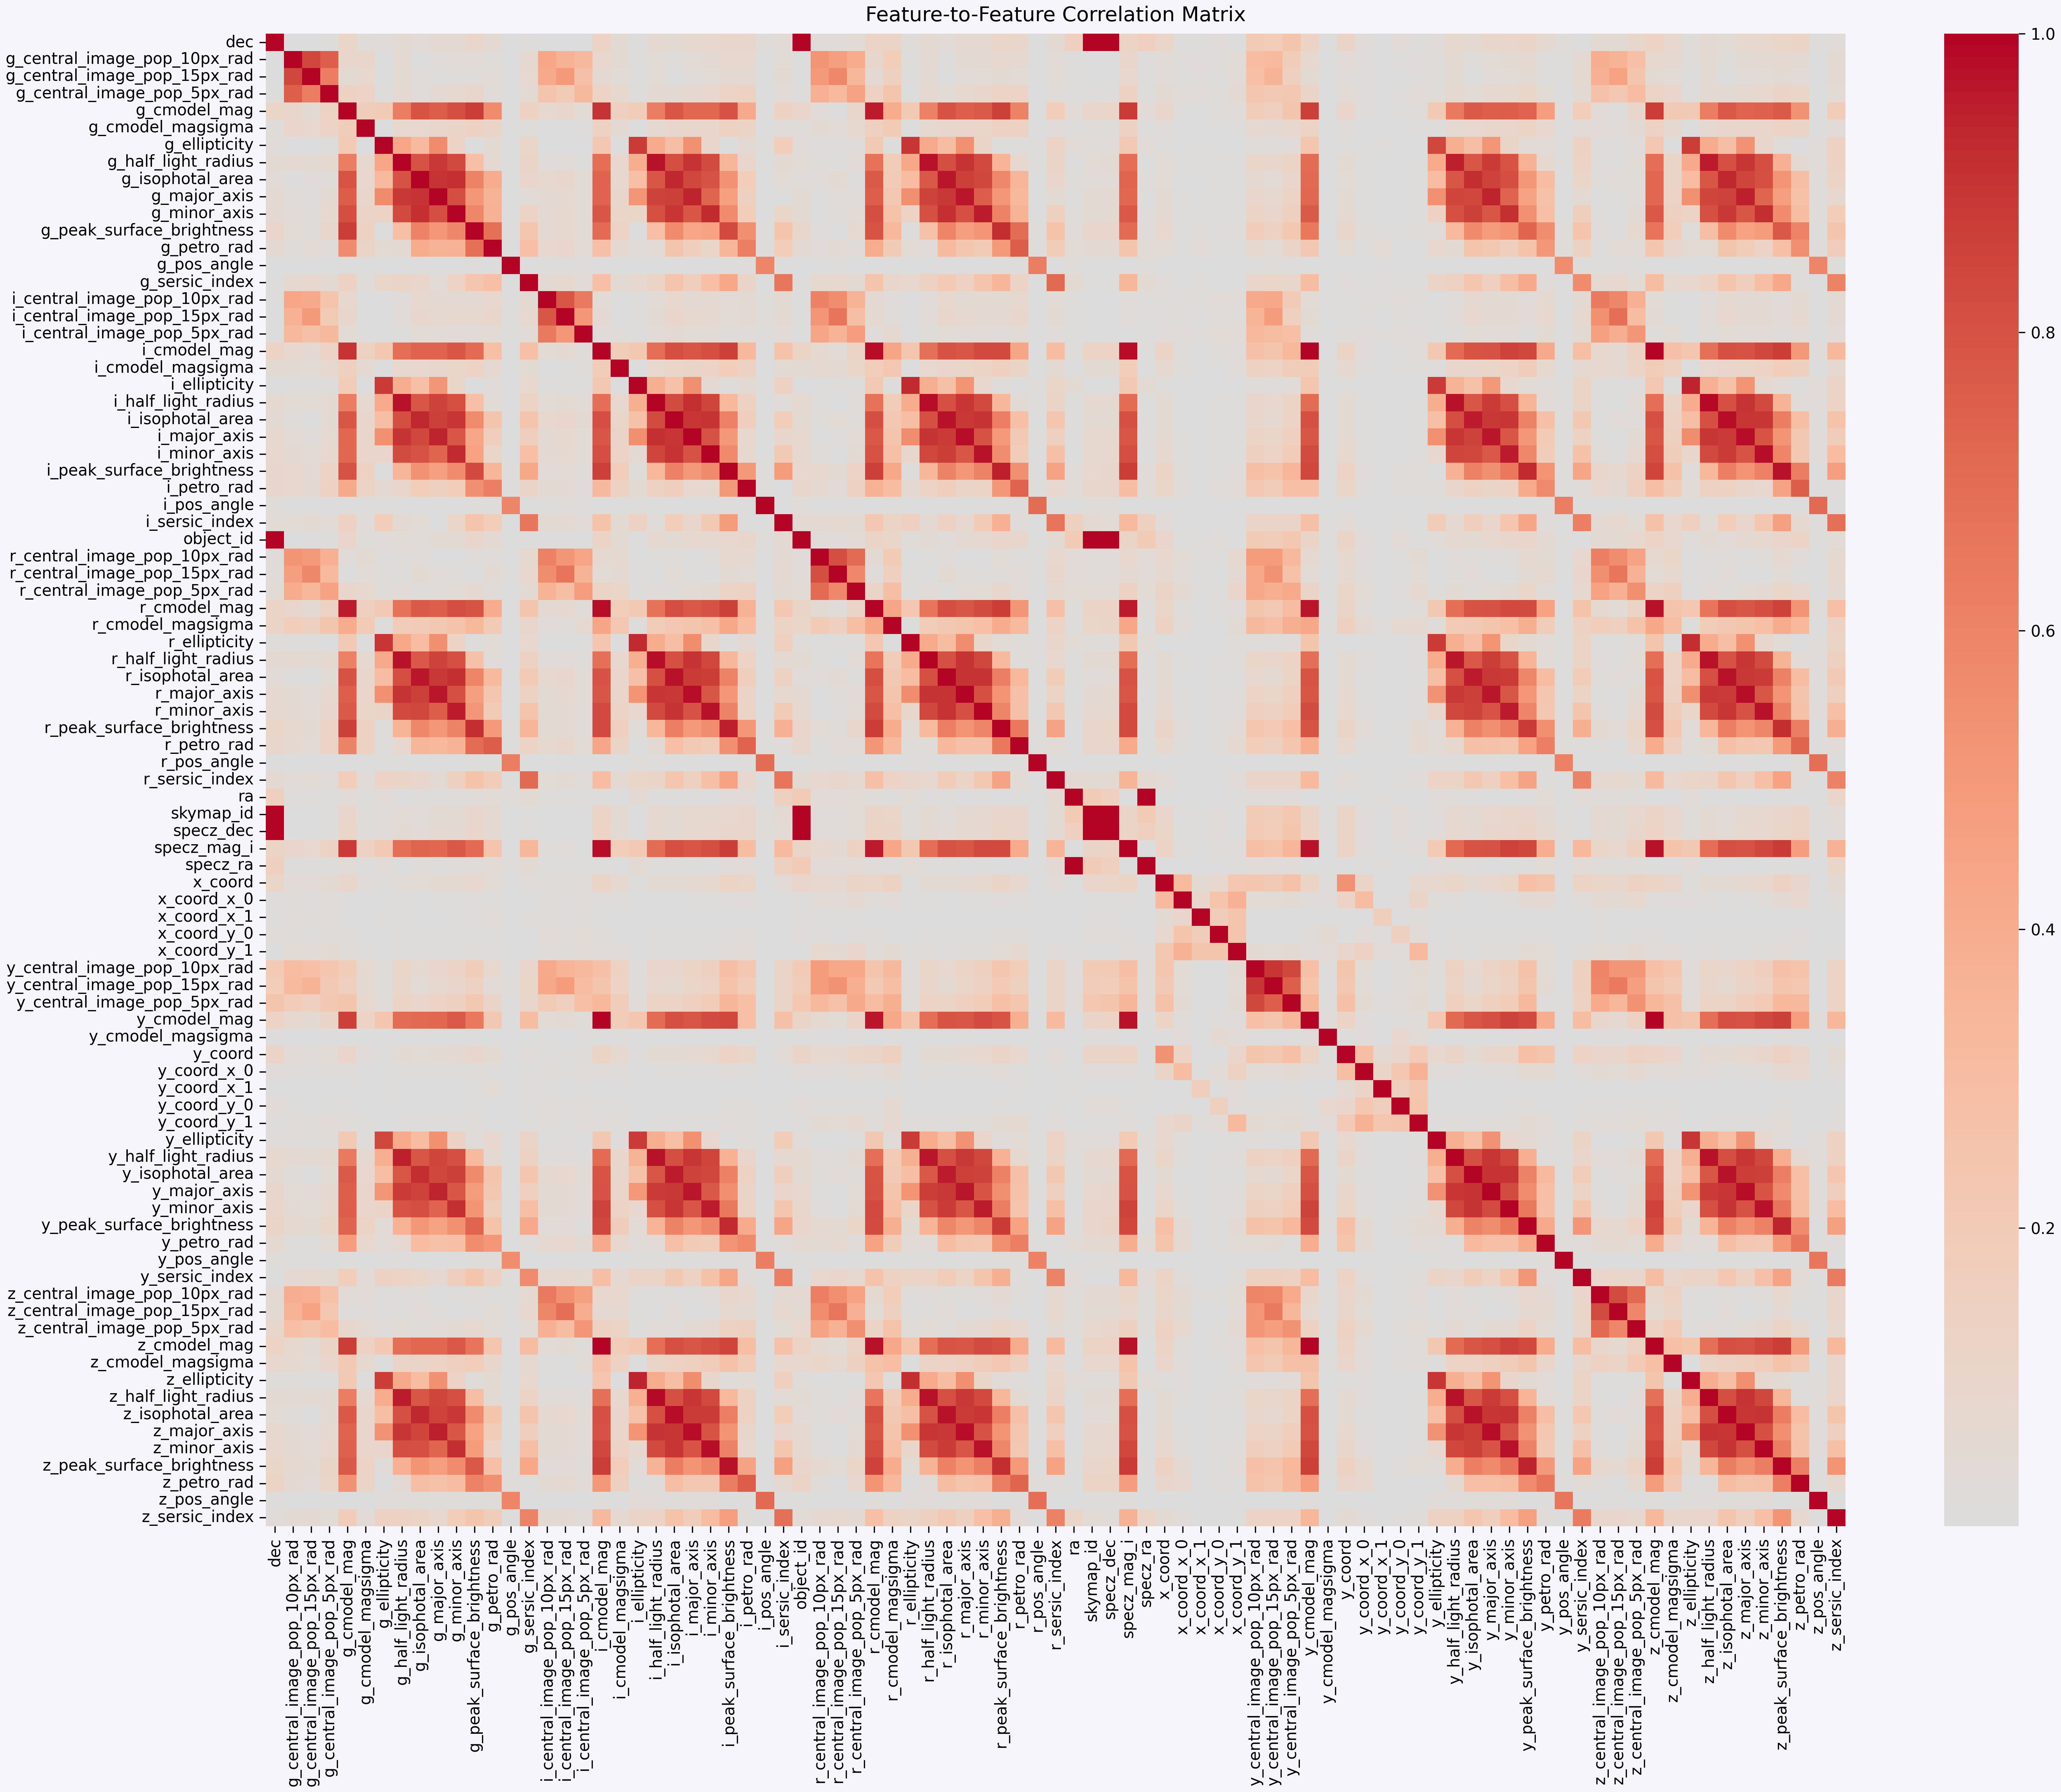

In [9]:
corr_matrix = df_train[numeric_cols].corr().abs()
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Feature-to-Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [10]:
HIGH_CORR = 0.3
LOW_CORR = 0.1

high = corr_with_label[corr_with_label >= HIGH_CORR]
medium = corr_with_label[(corr_with_label >= LOW_CORR) & (corr_with_label < HIGH_CORR)]
low = corr_with_label[corr_with_label < LOW_CORR]

print(f"High correlation (≥ 0.3):      {len(high)} features")
print(f"Medium correlation (0.1–0.3):  {len(medium)} features")
print(f"Low correlation (< 0.1):       {len(low)} features — candidates for removal")
print(f"\nHigh correlation features:")
print(high.to_string())

High correlation (≥ 0.3):      31 features
Medium correlation (0.1–0.3):  9 features
Low correlation (< 0.1):       47 features — candidates for removal

High correlation features:
i_major_axis           0.577381
z_major_axis           0.564428
i_minor_axis           0.563103
r_major_axis           0.555023
y_half_light_radius    0.551215
y_major_axis           0.550371
z_minor_axis           0.549891
i_half_light_radius    0.549300
z_half_light_radius    0.547114
r_half_light_radius    0.546777
y_cmodel_mag           0.542015
r_minor_axis           0.540682
y_minor_axis           0.539531
z_cmodel_mag           0.536351
g_half_light_radius    0.535512
i_cmodel_mag           0.526626
i_isophotal_area       0.520295
specz_mag_i            0.514988
z_isophotal_area       0.505264
g_major_axis           0.504444
r_isophotal_area       0.496845
g_minor_axis           0.486470
y_isophotal_area       0.485381
r_cmodel_mag           0.476916
g_isophotal_area       0.444069
z_ellipticity      

In [11]:
REDUNDANCY_THRESHOLD = 0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] >= REDUNDANCY_THRESHOLD
]
redundant_pairs.sort(key=lambda x: x[2], reverse=True)

print(f"Redundant feature pairs (|r| ≥ {REDUNDANCY_THRESHOLD}):")
for f1, f2, v in redundant_pairs:
    print(f"  {f1:<45s} <-> {f2:<45s}  r={v:.4f}")

Redundant feature pairs (|r| ≥ 0.95):
  specz_ra                                      <-> ra                                             r=1.0000
  specz_dec                                     <-> dec                                            r=1.0000
  skymap_id                                     <-> object_id                                      r=1.0000
  specz_dec                                     <-> object_id                                      r=0.9981
  object_id                                     <-> dec                                            r=0.9981
  specz_dec                                     <-> skymap_id                                      r=0.9981
  skymap_id                                     <-> dec                                            r=0.9981
  z_cmodel_mag                                  <-> y_cmodel_mag                                   r=0.9968
  z_cmodel_mag                                  <-> i_cmodel_mag                                  

In [12]:
X_tr = df_train[numeric_cols].values
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_tr)
zero_var = [numeric_cols[i] for i, v in enumerate(selector.variances_) if v == 0]
print(f"Zero-variance features (constant): {zero_var}")

Zero-variance features (constant): []


In [13]:
nan_counts = df_train[numeric_cols].isnull().sum()
inf_counts = df_train[numeric_cols].apply(lambda col: np.isinf(col).sum())
problems = pd.DataFrame({"nan_count": nan_counts, "inf_count": inf_counts})
bad = problems[(problems["nan_count"] + problems["inf_count"]) > 0]
if bad.empty:
    print("No NaN or Inf values found — data is clean.")
else:
    print(bad.to_string())

No NaN or Inf values found — data is clean.


In [14]:
to_drop = set()
to_drop.update(zero_var)
to_drop.update(low.index.tolist())
to_drop.update(f2 for _, f2, _ in redundant_pairs)

final_features = [f for f in numeric_cols if f not in to_drop]

print(f"Dropped — zero variance: {len(zero_var)}, "
      f"low correlation: {len(low)}, "
      f"redundant: {len(set(f2 for _,f2,_ in redundant_pairs))}")
print(f"Features before: {len(numeric_cols)}  →  after: {len(final_features)}")
print(f"\nFinal feature set: {final_features}")

Dropped — zero variance: 0, low correlation: 47, redundant: 26
Features before: 87  →  after: 18

Final feature set: ['g_ellipticity', 'g_sersic_index', 'i_ellipticity', 'r_cmodel_magsigma', 'r_ellipticity', 'r_peak_surface_brightness', 'y_central_image_pop_10px_rad', 'y_central_image_pop_5px_rad', 'y_ellipticity', 'y_peak_surface_brightness', 'z_cmodel_mag', 'z_cmodel_magsigma', 'z_ellipticity', 'z_half_light_radius', 'z_isophotal_area', 'z_major_axis', 'z_minor_axis', 'z_peak_surface_brightness']


Decision Tree (val) — RMSE: 0.2956 | NMAD: 0.0685 | Outlier%: 13.78%


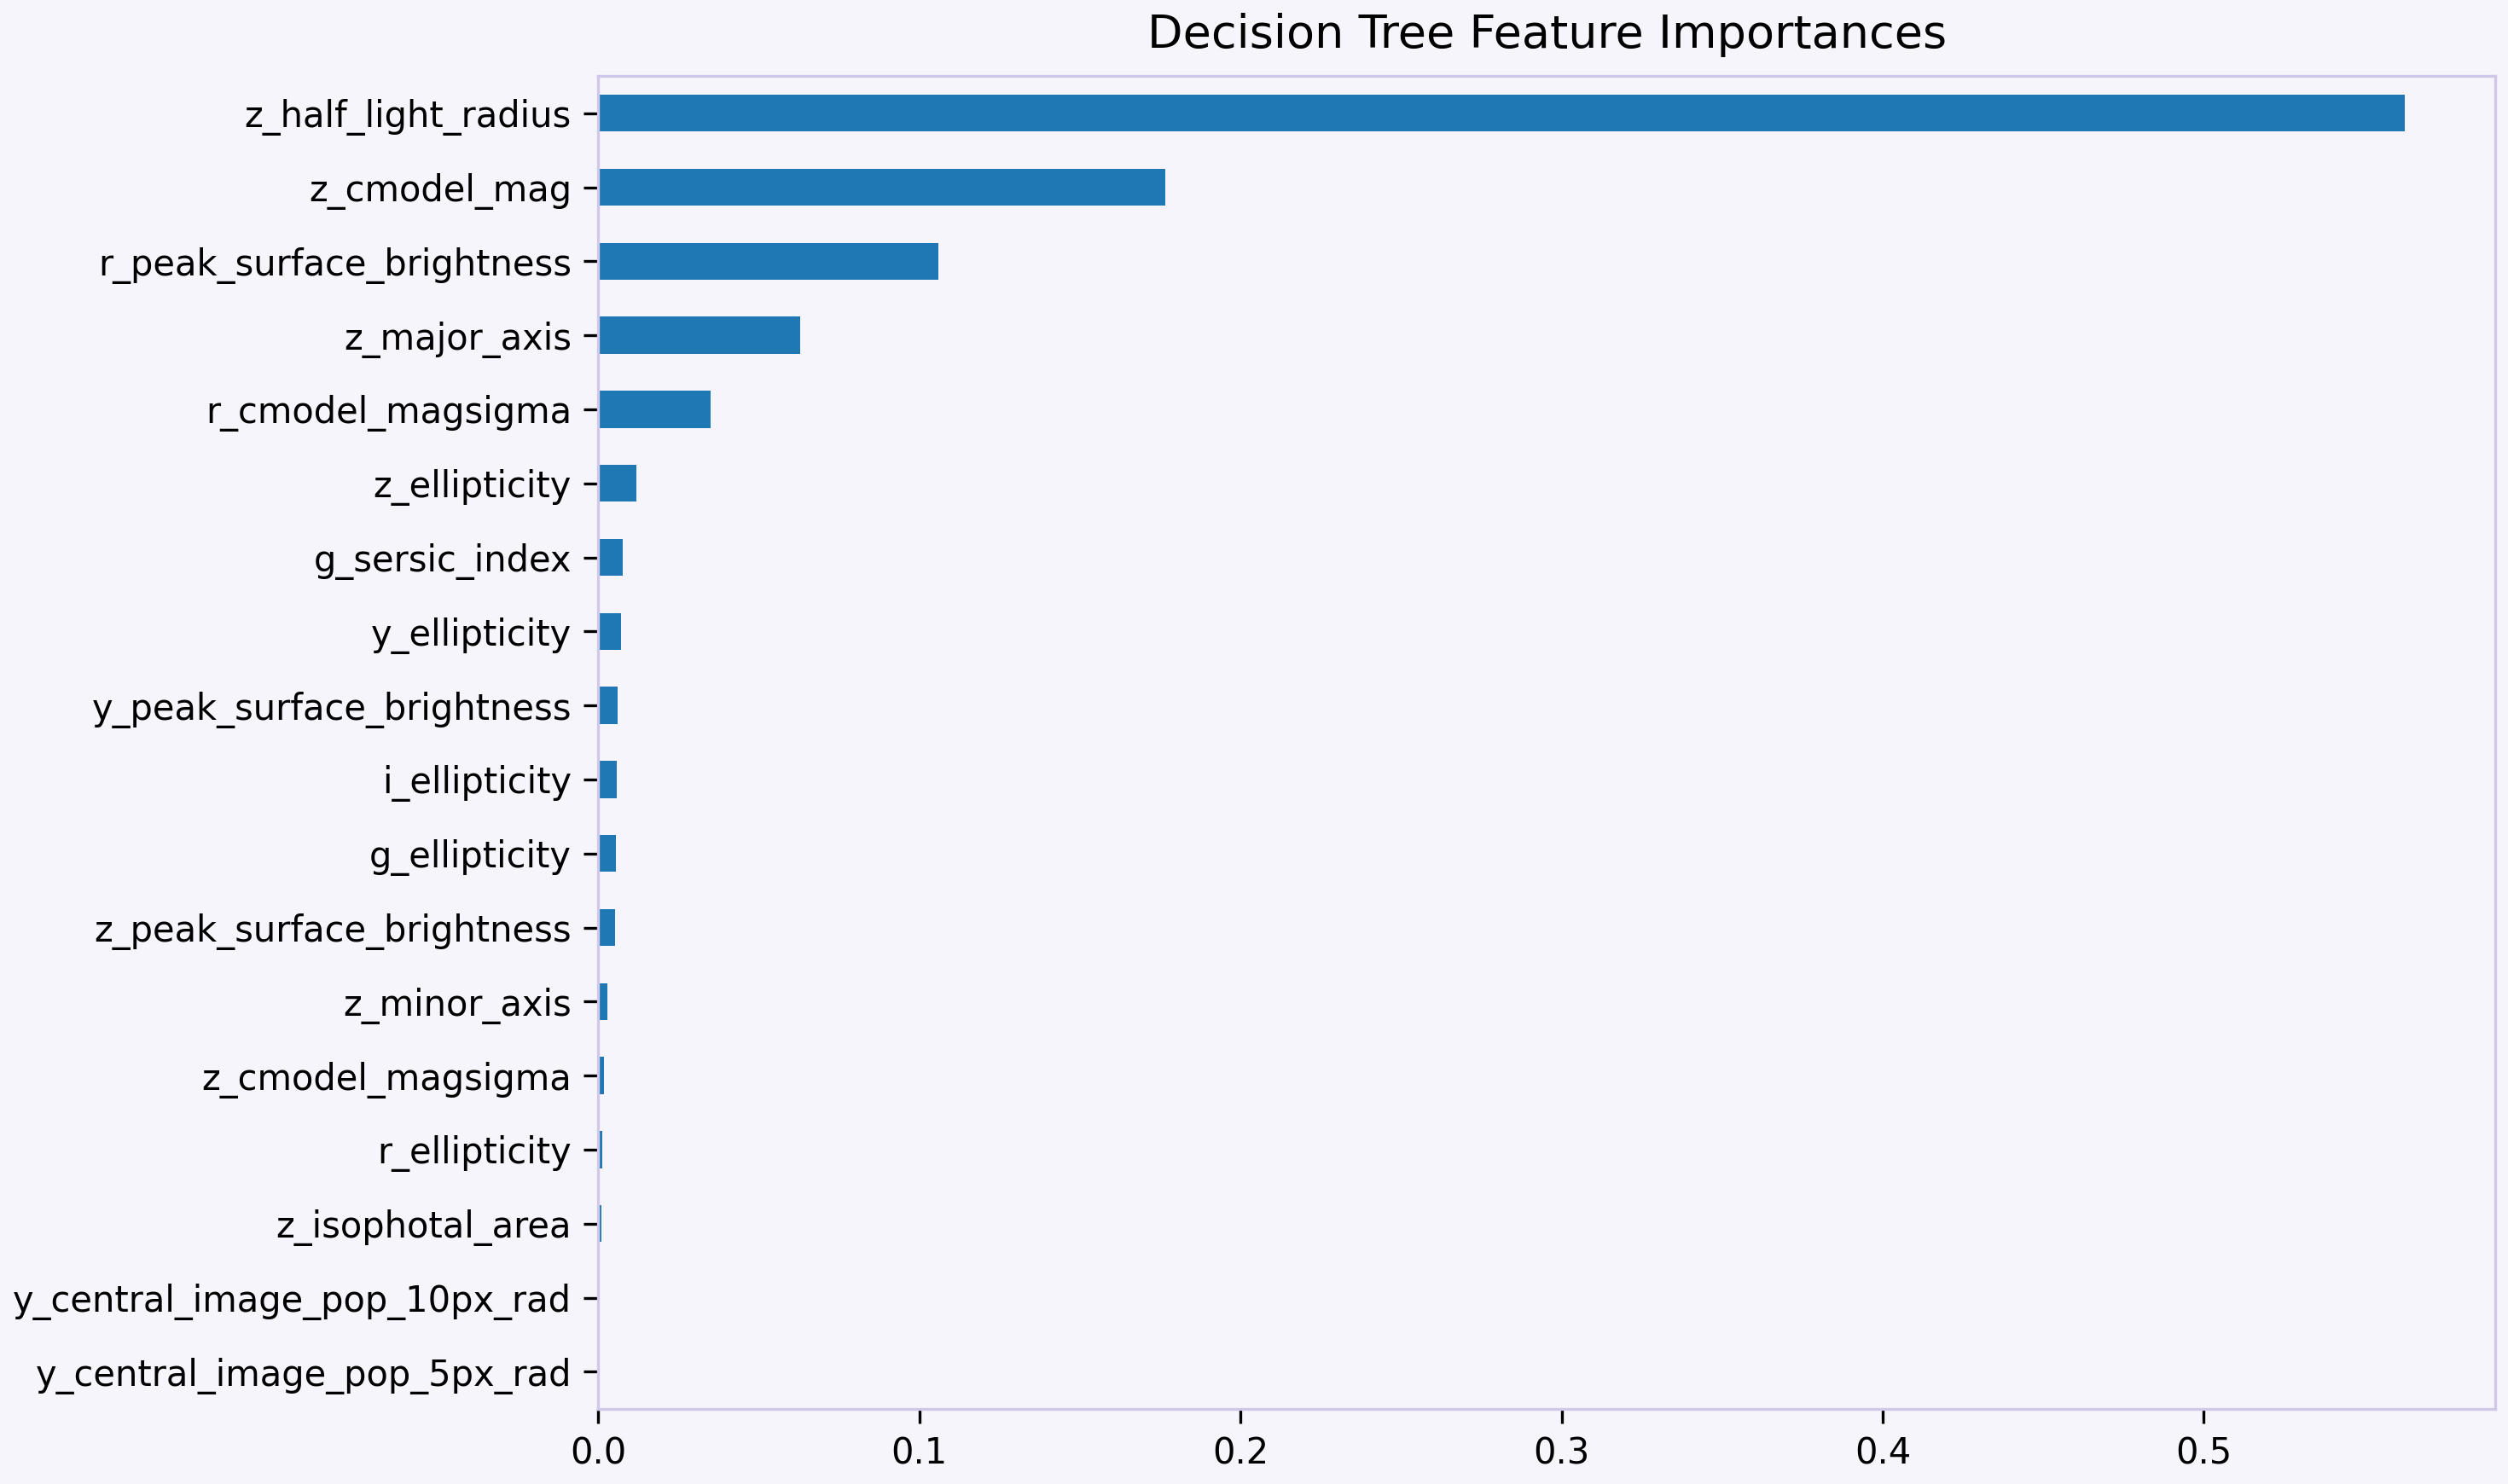

In [15]:
X_train_final = df_train[final_features].values.astype(np.float64)
X_val_final = df_val[final_features].values.astype(np.float64)
y_train_final = df_train["specz_redshift"].values
y_val_final = df_val["specz_redshift"].values

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_final, y_train_final)
y_pred_dt = dt.predict(X_val_final)

m_dt = redshift_metrics(y_pred_dt, y_val_final)
print(f"Decision Tree (val) — RMSE: {m_dt['rmse']:.4f} | NMAD: {m_dt['nmad']:.4f} | "
      f"Outlier%: {m_dt['outlier_pct']:.2f}%")

importances = pd.Series(dt.feature_importances_, index=final_features).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

## 4. Tabular Models


In [16]:
top5_features = [
    "z_half_light_radius",
    "z_cmodel_mag",
    "r_peak_surface_brightness",
    "z_major_axis",
    "r_cmodel_magsigma",
]

X_train_top5 = df_train[top5_features].values.astype(np.float64)
X_val_top5 = df_val[top5_features].values.astype(np.float64)
X_test_top5 = df_test[top5_features].values.astype(np.float64)

y_train_raw = df_train["specz_redshift"].values
y_val_raw = df_val["specz_redshift"].values
y_test_raw = df_test["specz_redshift"].values

test_mask = (y_test_raw >= 0.0) & (y_test_raw <= 2.5)
X_test_top5 = X_test_top5[test_mask]
y_test = y_test_raw[test_mask]
y_true_primary = y_test

y_train = y_train_raw
y_val = y_val_raw

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_top5)
X_val_sc = scaler.transform(X_val_top5)
X_test_sc = scaler.transform(X_test_top5)

SCALED_MODELS = {"Ridge", "kNN", "MLP"}
print(f"Top-5 features: {top5_features}")
print(f"Test set (0.0–2.5): {test_mask.sum():,} / {len(y_test_raw):,} galaxies")

Top-5 features: ['z_half_light_radius', 'z_cmodel_mag', 'r_peak_surface_brightness', 'z_major_axis', 'r_cmodel_magsigma']
Test set (0.0–2.5): 40,039 / 40,914 galaxies


In [17]:
base_models = {
    "Ridge": Ridge(),
    "kNN": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

print(f"{'Model':<22} {'RMSE':>7} {'MAE':>7} {'NMAD':>7} {'Outlier%':>9} {'R²':>7}")
print("-" * 60)

trained_models = {}
for name, model in base_models.items():
    X_tr = X_train_sc if name in SCALED_MODELS else X_train_top5
    X_vl = X_val_sc if name in SCALED_MODELS else X_val_top5
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_vl)
    m = redshift_metrics(y_pred, y_val)
    print(f"{name:<22} {m['rmse']:>7.4f} {m['mae']:>7.4f} {m['nmad']:>7.4f} "
          f"{m['outlier_pct']:>8.2f}% {m['r2']:>7.4f}")
    trained_models[name] = model

Model                     RMSE     MAE    NMAD  Outlier%      R²
------------------------------------------------------------
Ridge                   0.4269  0.2838  0.1910    44.17%  0.4293
kNN                     0.3092  0.1609  0.0753    15.43%  0.7006
Random Forest           0.2911  0.1493  0.0674    13.83%  0.7345
Gradient Boosting       0.2954  0.1599  0.0798    15.82%  0.7266
MLP                     0.2926  0.1520  0.0728    14.25%  0.7318


In [18]:
MODEL_NAME_MAP = {
    "Ridge":            "ridge",
    "kNN":              "knn",
    "Random Forest":    "rf",
    "Gradient Boosting":"gb",
    "MLP":              "mlp",
}

for name, model in trained_models.items():
    fname = f"{MODEL_NAME_MAP[name]}_model.pkl"
    save_path = os.path.join(BASE_MODELS, fname)
    joblib.dump(model, save_path)
    print(f"Saved {name} → {save_path}")

joblib.dump(scaler, os.path.join(BASE_MODELS, "tabular_scaler.pkl"))
print("Saved scaler → tabular_scaler.pkl")

Saved Ridge → /Users/arpinejanunts/Desktop/Capstone/models/ridge_model.pkl
Saved kNN → /Users/arpinejanunts/Desktop/Capstone/models/knn_model.pkl
Saved Random Forest → /Users/arpinejanunts/Desktop/Capstone/models/rf_model.pkl
Saved Gradient Boosting → /Users/arpinejanunts/Desktop/Capstone/models/gb_model.pkl
Saved MLP → /Users/arpinejanunts/Desktop/Capstone/models/mlp_model.pkl
Saved scaler → tabular_scaler.pkl


In [18]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(mean_squared_error, greater_is_better=False)

print(f"{'Model':<22} {'Mean RMSE':>10} {'± Std':>8}")
print("-" * 44)

for name, model in base_models.items():
    X_tr = X_train_sc if name in SCALED_MODELS else X_train_top5
    scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring=scorer, n_jobs=-1)
    rmse = np.sqrt(-scores)
    print(f"{name:<22} {rmse.mean():>10.5f} {rmse.std():>8.5f}")

Model                   Mean RMSE    ± Std
--------------------------------------------
Ridge                     0.43244  0.00317
kNN                       0.31053  0.00262
Random Forest             0.29162  0.00270
Gradient Boosting         0.29756  0.00190
MLP                       0.29330  0.00239


## 5. Tabular Model Evaluation on Test Set


In [22]:
tabular_preds = {}

for name, model in base_models.items():
    X_te = X_test_sc if name in SCALED_MODELS else X_test_top5
    tabular_preds[name] = model.predict(X_te)

### 5.1 Random Forest

In [24]:
y_pred_rf = tabular_preds["Random Forest"]
m = redshift_metrics(y_pred_rf, y_test)
for k, v in m.items(): print(f"  {k:<28} {v:.5f}")
evaluate_by_bin(y_test, y_pred_rf, bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

  rmse                         0.24531
  mae                          0.13084
  bias                         0.00491
  r2                           0.70126
  nmad                         0.06572
  outlier_pct                  12.19561
  cat_outlier_pct              4.37823
  three_sigma_outlier_pct      8.22198
  outlier_abs_pct              1.36367
  lsst_cat_outlier_pct         1.36367
  within_0.1z                  0.79120
  within_0.05z                 0.54939

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.2048   0.0745     10.95%       0.89%   0.0069
0.5–1.0       14,815   0.2218   0.0587      9.01%       1.24%  -0.0023
1.0–1.5        2,069   0.4575   0.1523     46.69%       3.19%  -0.0699
1.5–2.0          938   0.4627   0.1559     38.06%       2.56%   0.0462
2.0–2.5        1,047   0.6059   0.1206     32.47%      13.09%  -0.0917


,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.204813,0.074527,10.947894,0.886918,0.006919
1,0.5–1.0,14815,0.221799,0.058734,9.011137,1.241984,-0.002318
2,1.0–1.5,2069,0.457508,0.152318,46.689222,3.189947,-0.069866
3,1.5–2.0,938,0.462699,0.155901,38.059701,2.558635,0.046209
4,2.0–2.5,1047,0.605860,0.120594,32.473734,13.085005,-0.091688


In [25]:
np.save(os.path.join(BASE_MODELS, "rf_ypred.npy"), y_pred_rf)
np.save(os.path.join(BASE_MODELS, "rf_ytrue.npy"), y_test)

### 5.2 Ridge

In [27]:
y_pred_ridge = tabular_preds["Ridge"]
m = redshift_metrics(y_pred_ridge, y_test)
for k, v in m.items(): print(f"  {k:<28} {v:.5f}")
evaluate_by_bin(y_test, y_pred_ridge, bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

  rmse                         0.34669
  mae                          0.25257
  bias                         0.03886
  r2                           0.40331
  nmad                         0.18635
  outlier_pct                  43.06801
  cat_outlier_pct              16.12428
  three_sigma_outlier_pct      1.79825
  outlier_abs_pct              2.19036
  lsst_cat_outlier_pct         2.19036
  within_0.1z                  0.41067
  within_0.05z                 0.21594

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.2964   0.1398     36.81%       0.18%   0.0845
0.5–1.0       14,815   0.2557   0.1454     30.91%       0.13%   0.0044
1.0–1.5        2,069   0.2563   0.0989     18.51%       0.10%  -0.0580
1.5–2.0          938   0.5902   0.0603     77.40%       0.75%  -0.1967
2.0–2.5        1,047   1.1007   0.0414     99.81%      70.96%  -0.3344


,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.296350,0.139843,36.807095,0.180155,0.084486
1,0.5–1.0,14815,0.255697,0.145422,30.907864,0.134998,0.004369
2,1.0–1.5,2069,0.256266,0.098881,18.511358,0.096665,-0.058024
3,1.5–2.0,938,0.590215,0.060274,77.398721,0.746269,-0.196725
4,2.0–2.5,1047,1.100674,0.041415,99.808978,70.964661,-0.334387


In [28]:
np.save(os.path.join(BASE_MODELS, "ridge_ypred.npy"), y_pred_ridge)
np.save(os.path.join(BASE_MODELS, "ridge_ytrue.npy"), y_test)

### 5.3 kNN

In [29]:
y_pred_knn = tabular_preds["kNN"]
m = redshift_metrics(y_pred_knn, y_test)
for k, v in m.items(): print(f"  {k:<28} {v:.5f}")
evaluate_by_bin(y_test, y_pred_knn, bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

  rmse                         0.26483
  mae                          0.14282
  bias                         0.00424
  r2                           0.65184
  nmad                         0.07306
  outlier_pct                  13.92392
  cat_outlier_pct              4.75786
  three_sigma_outlier_pct      7.78491
  outlier_abs_pct              1.62841
  lsst_cat_outlier_pct         1.62841
  within_0.1z                  0.75549
  within_0.05z                 0.50643

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.2222   0.0845     11.71%       0.97%   0.0021
0.5–1.0       14,815   0.2413   0.0636     10.66%       1.51%  -0.0037
1.0–1.5        2,069   0.4936   0.1578     48.96%       4.88%  -0.0733
1.5–2.0          938   0.5135   0.1784     42.54%       5.44%   0.0343
2.0–2.5        1,047   0.6405   0.1415     38.87%      11.94%  -0.1006


,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.222240,0.084504,11.710089,0.970067,0.002126
1,0.5–1.0,14815,0.241259,0.063585,10.664867,1.511981,-0.003654
2,1.0–1.5,2069,0.493561,0.157779,48.960851,4.881585,-0.073304
3,1.5–2.0,938,0.513495,0.178426,42.537313,5.437100,0.034282
4,2.0–2.5,1047,0.640496,0.141536,38.872970,11.938873,-0.100573


In [30]:
np.save(os.path.join(BASE_MODELS, "knn_ypred.npy"), y_pred_knn)
np.save(os.path.join(BASE_MODELS, "knn_ytrue.npy"), y_test)

### 5.4 Gradient Boosting

In [31]:
y_pred_gb = tabular_preds["Gradient Boosting"]
m = redshift_metrics(y_pred_gb, y_test)
for k, v in m.items(): print(f"  {k:<28} {v:.5f}")
evaluate_by_bin(y_test, y_pred_gb, bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

  rmse                         0.24713
  mae                          0.14090
  bias                         0.00336
  r2                           0.69682
  nmad                         0.07763
  outlier_pct                  14.07877
  cat_outlier_pct              5.05257
  three_sigma_outlier_pct      7.49769
  outlier_abs_pct              1.26876
  lsst_cat_outlier_pct         1.26876
  within_0.1z                  0.75299
  within_0.05z                 0.48590

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.2112   0.0940     14.47%       0.82%   0.0051
0.5–1.0       14,815   0.2145   0.0609      8.30%       1.22%  -0.0100
1.0–1.5        2,069   0.4434   0.1335     50.31%       1.79%  -0.0868
1.5–2.0          938   0.4568   0.1621     38.06%       2.77%   0.0259
2.0–2.5        1,047   0.6380   0.1144     37.15%      14.33%  -0.1083


,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.211244,0.093995,14.467849,0.817627,0.005087
1,0.5–1.0,14815,0.214511,0.060922,8.295646,1.221735,-0.010026
2,1.0–1.5,2069,0.443446,0.133503,50.314161,1.788304,-0.086845
3,1.5–2.0,938,0.456760,0.162095,38.059701,2.771855,0.025870
4,2.0–2.5,1047,0.637991,0.114394,37.153773,14.326648,-0.108267


In [32]:
np.save(os.path.join(BASE_MODELS, "gb_ypred.npy"), y_pred_gb)
np.save(os.path.join(BASE_MODELS, "gb_ytrue.npy"), y_test)

### 5.5 MLP

In [33]:
# MLP
y_pred_mlp = tabular_preds["MLP"]
m = redshift_metrics(y_pred_mlp, y_test)
for k, v in m.items(): print(f"  {k:<28} {v:.5f}")
evaluate_by_bin(y_test, y_pred_mlp, bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

  rmse                         0.34807
  mae                          0.13166
  bias                         0.00551
  r2                           0.39856
  nmad                         0.07037
  outlier_pct                  12.41290
  cat_outlier_pct              3.97612
  three_sigma_outlier_pct      7.19049
  outlier_abs_pct              1.03899
  lsst_cat_outlier_pct         1.03899
  within_0.1z                  0.77732
  within_0.05z                 0.52361

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.1891   0.0771     10.93%       0.60%   0.0037
0.5–1.0       14,815   0.2030   0.0610      8.17%       0.86%   0.0016
1.0–1.5        2,069   0.4061   0.1497     46.50%       0.53%  -0.0803
1.5–2.0          938   1.7207   0.1259     28.46%       2.77%  -0.0008
2.0–2.5        1,047   0.6750   0.1001     45.65%      14.14%  -0.1380


,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.189147,0.077079,10.934035,0.595898,0.003709
1,0.5–1.0,14815,0.203038,0.061020,8.174148,0.857239,0.001567
2,1.0–1.5,2069,0.406074,0.149681,46.495892,0.531658,-0.080304
3,1.5–2.0,938,1.720704,0.125949,28.464819,2.771855,-0.000816
4,2.0–2.5,1047,0.675046,0.100072,45.654250,14.135626,-0.137956


In [34]:
np.save(os.path.join(BASE_MODELS, "mlp_ypred.npy"), y_pred_mlp)
np.save(os.path.join(BASE_MODELS, "mlp_ytrue.npy"), y_test)

## 6. Image Data Loading

In [35]:
with h5py.File(TRAIN_PATH, "r") as f:
    shape = f["image"].shape
    n_flags = f["specz_flag_homogeneous"][:].astype(bool).sum()

print(f"Full train tensor shape : {shape}  (dtype float32)")
print(f"Valid galaxies (flagged): {n_flags:,}")
print(f"Estimated RAM (float32) : {n_flags * 5 * 127 * 127 * 4 / 1e9:.2f} GB — "
      f"hence lazy HDF5 loading via DataLoader")

Full train tensor shape : (204573, 5, 127, 127)  (dtype float32)
Valid galaxies (flagged): 204,573
Estimated RAM (float32) : 65.99 GB — hence lazy HDF5 loading via DataLoader


In [36]:
train_loader, val_loader, test_loader = get_dataloaders(
    TRAIN_PATH, VAL_PATH, TEST_PATH,
    batch_size=64,
    num_workers=0,
)

print(f"Train : {len(train_loader.dataset):,} galaxies  ({len(train_loader)} batches)")
print(f"Val   : {len(val_loader.dataset):,} galaxies  ({len(val_loader)} batches)")
print(f"Test  : {len(test_loader.dataset):,} galaxies  ({len(test_loader)} batches)")

x_batch, y_batch = next(iter(train_loader))
print(f"\nBatch image shape : {x_batch.shape}   (B, 5, 127, 127)")
print(f"Pixel range       : [{x_batch.min():.3f}, {x_batch.max():.3f}]")
print(f"Pixel mean / std  : {x_batch.mean():.4f} / {x_batch.std():.4f}")
print(f"Redshift range    : [{y_batch.min():.4f}, {y_batch.max():.4f}]")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples
Train : 204,573 galaxies  (3197 batches)
Val   : 40,914 galaxies  (640 batches)
Test  : 40,914 galaxies  (640 batches)

Batch image shape : torch.Size([64, 5, 127, 127])   (B, 5, 127, 127)
Pixel range       : [-0.924, 161.128]
Pixel mean / std  : 0.0197 / 0.9446
Redshift range    : [0.0453, 2.7561]


## 7. Simple CNN

In [38]:
def train_cnn(
    model,
    train_loader,
    val_loader,
    epochs: int = 20,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    grad_clip: float = 1.0,
    save_best_path: str = None,
    patience: int = 5,
):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                       patience=3, factor=0.5)
    criterion = nn.SmoothL1Loss(beta=0.5)

    best_val = float("inf")
    no_improve = 0
    train_losses = []
    val_losses = []

    template = dict(model_name="GalaxiesMLCNN", batch_size=train_loader.batch_size,
                    optimizer="AdamW", lr=lr, weight_decay=weight_decay)

    for epoch in tqdm(range(epochs), desc="Training CNN", unit="epoch"):
        model.train()
        train_sum, train_n = 0.0, 0
        for X, y in train_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(X), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_sum += loss.item() * len(y)
            train_n += len(y)

        model.eval()
        val_sum, val_n = 0.0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                val_sum += criterion(model(X), y).item() * len(y)
                val_n += len(y)

        t_loss = train_sum / train_n
        v_loss = val_sum / val_n
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        scheduler.step(v_loss)

        if v_loss < best_val:
            best_val = v_loss
            no_improve = 0
            if save_best_path:
                save_checkpoint(
                    save_best_path, model, optimizer, scheduler, epoch,
                    best_val, no_improve, train_losses, val_losses,
                    template=template,
                )
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    print(f"Best val SmoothL1 loss: {best_val:.6f}")
    return train_losses, val_losses

In [ ]:
CNN_BEST_PATH = os.path.join(BASE_MODELS, "best_cnn.pt")

cnn = GalaxiesMLCNN(in_channels=5, width=32, dropout=0.15)
train_losses, val_losses = train_cnn(
    cnn, train_loader, val_loader,
    epochs=20, lr=1e-3,
    save_best_path=CNN_BEST_PATH,
    patience=5,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train Loss")
ax.plot(val_losses, label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("SmoothL1 Loss")
ax.set_title("CNN Training Curves")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_REPORTS, "cnn_learning_curve.png"), dpi=150)
plt.show()

In [ ]:
cnn_eval = GalaxiesMLCNN(in_channels=5, width=32, dropout=0.15)

cnn_eval.head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(256, 256), 
    nn.SiLU(inplace=True),
    nn.Dropout(0.15),
    nn.Linear(256, 1), 
)

cnn_eval.backbone.add_module("4", nn.Sequential(
    nn.Conv2d(256, 256, 3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.SiLU(inplace=True),
))

ckpt = torch.load(CNN_BEST_PATH, map_location=device, weights_only=False)
cnn_eval.load_state_dict(ckpt["model"], strict=False)  # backbone.4 still unexpected
cnn_eval = cnn_eval.to(device)

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds = []
    for X, _ in tqdm(loader, desc="Predicting", unit="batch"):
        preds.append(model(X.to(device)).cpu().numpy())
    return np.concatenate(preds).flatten()

y_pred_cnn_all = predict_loader(cnn_eval, test_loader)
y_pred_cnn = y_pred_cnn_all[test_mask]

print(f"Predictions shape : {y_pred_cnn.shape}")
print(f"Pred range        : [{y_pred_cnn.min():.4f}, {y_pred_cnn.max():.4f}]")

Predicting:   0%|          | 0/640 [00:00<?, ?batch/s]

Predictions shape : (40039,)
Pred range        : [0.0198, 2.8426]


In [52]:
np.save(os.path.join(BASE_MODELS, "cnn_ypred.npy"), y_pred_cnn)
np.save(os.path.join(BASE_MODELS, "cnn_ytrue.npy"), y_test)

### 7.3 CNN Evaluation

In [53]:
print("\nFull metric suite:")
m_cnn = redshift_metrics(y_pred_cnn, y_test)
for k, v in m_cnn.items():
    print(f"  {k:<28} {v:.5f}")

evaluate_by_bin(y_test, y_pred_cnn, bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])


Full metric suite:
  rmse                         0.21636
  mae                          0.11868
  bias                         0.05009
  r2                           0.76761
  nmad                         0.05269
  outlier_pct                  7.49020
  cat_outlier_pct              2.84223
  three_sigma_outlier_pct      5.30483
  outlier_abs_pct              1.29624
  lsst_cat_outlier_pct         1.29624
  within_0.1z                  0.83981
  within_0.05z                 0.45608

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.1611   0.0310      5.47%       0.37%   0.0700
0.5–1.0       14,815   0.2142   0.0352      3.37%       1.54%   0.0595
1.0–1.5        2,069   0.4730   0.0843     25.04%       8.55%   0.0215
1.5–2.0          938   0.3967   0.0846     30.92%       0.75%   0.0920
2.0–2.5        1,047   0.3054   0.0342      7.83%       3.06%   0.0250


,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.161101,0.030979,5.473947,0.374169,0.069991
1,0.5–1.0,14815,0.214158,0.035186,3.374958,1.538981,0.059497
2,1.0–1.5,2069,0.473030,0.084256,25.036249,8.554857,0.021535
3,1.5–2.0,938,0.396706,0.084622,30.916844,0.746269,0.092007
4,2.0–2.5,1047,0.305364,0.034236,7.831901,3.056351,0.024960


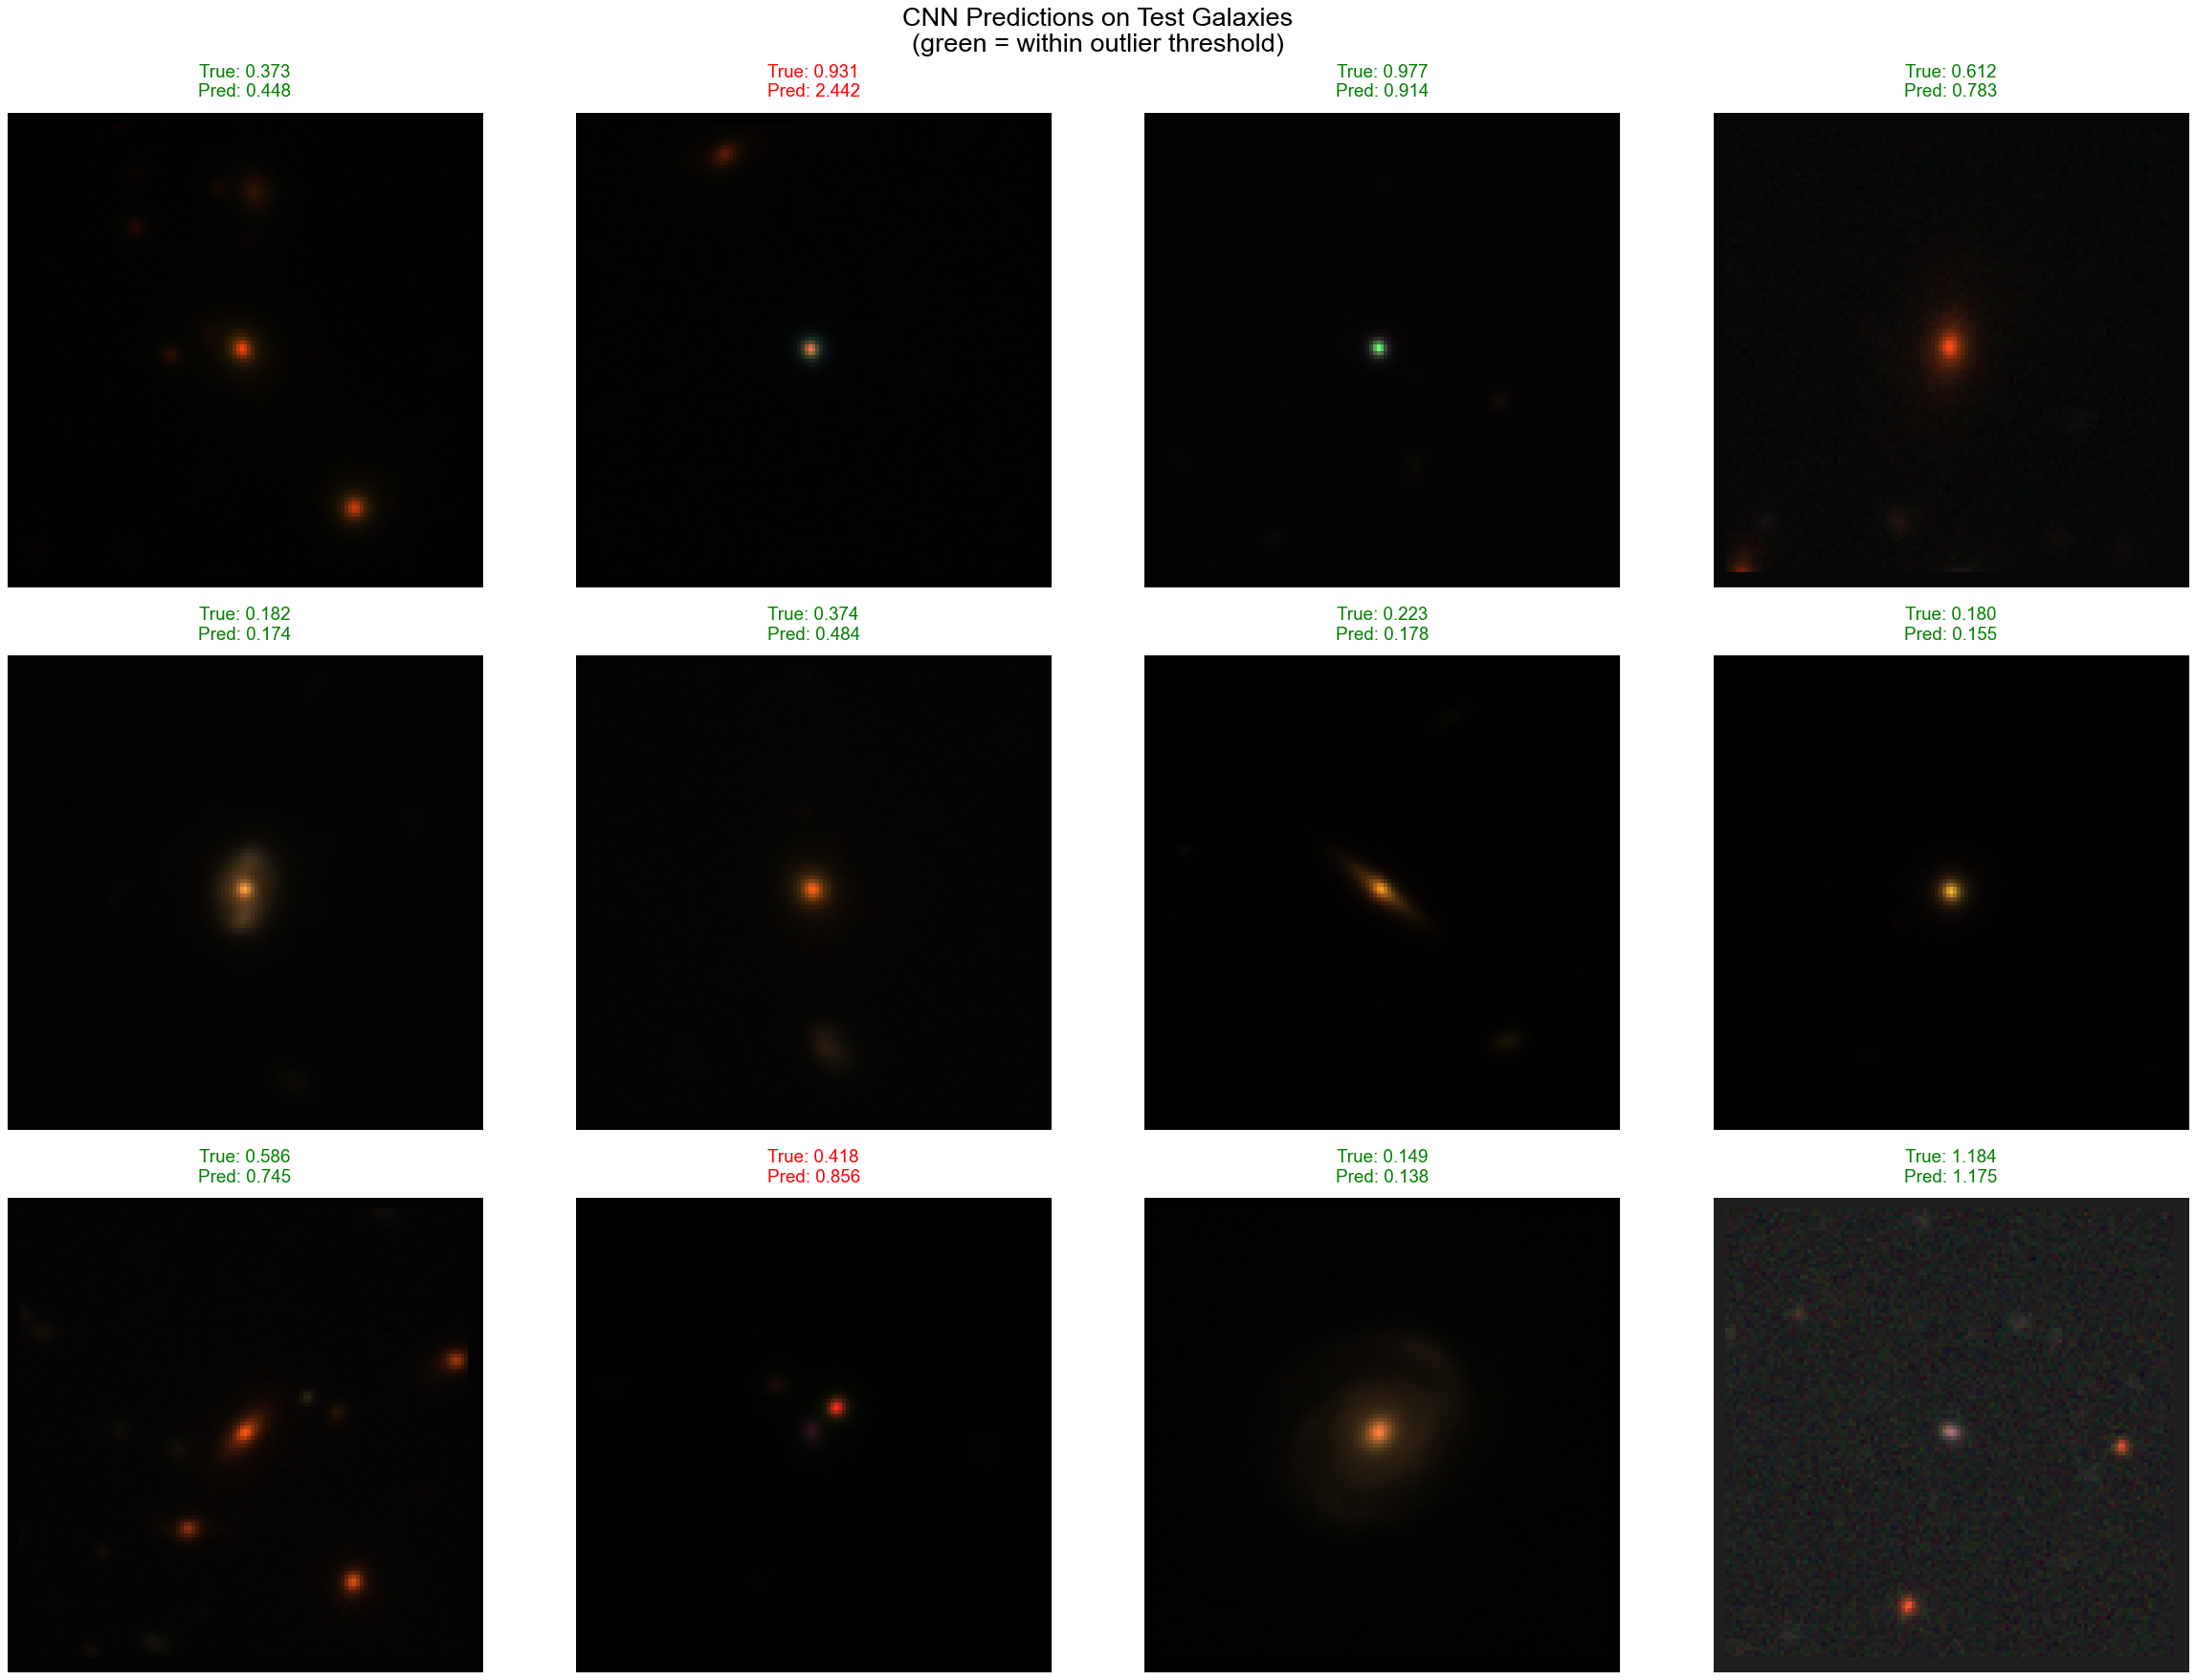

In [55]:
test_dataset = test_loader.dataset

def visualize_predictions_on_images(model, dataset, num_samples=12):
    model.eval()
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    with torch.no_grad():
        for ax, idx in zip(axes.flat, indices):
            x, y_true = dataset[idx]
            y_pred_val = model(x.unsqueeze(0).to(device)).item()
            y_true_val = y_true.item()

            std = BAND_STD.squeeze().numpy()
            mean = BAND_MEAN.squeeze().numpy()
            img = x.numpy() * std[:, None, None] + mean[:, None, None]
            rgb = np.stack([img[2], img[1], img[0]], axis=-1)
            rgb = np.clip((rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8), 0, 1)

            ax.imshow(rgb)
            color = "green" if abs(y_pred_val - y_true_val) / (1 + y_true_val) < 0.15 else "red"
            ax.set_title(f"True: {y_true_val:.3f}\nPred: {y_pred_val:.3f}", fontsize=9, color=color)
            ax.axis("off")

    fig.suptitle("CNN Predictions on Test Galaxies", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_REPORTS, "cnn_predictions_on_images.png"), dpi=150)
    plt.show()

visualize_predictions_on_images(cnn_eval, test_dataset)

### 7.2 CNN Visualization

Scatter plot saved → /Users/arpinejanunts/Desktop/Capstone/reports/cnn_scatter.png


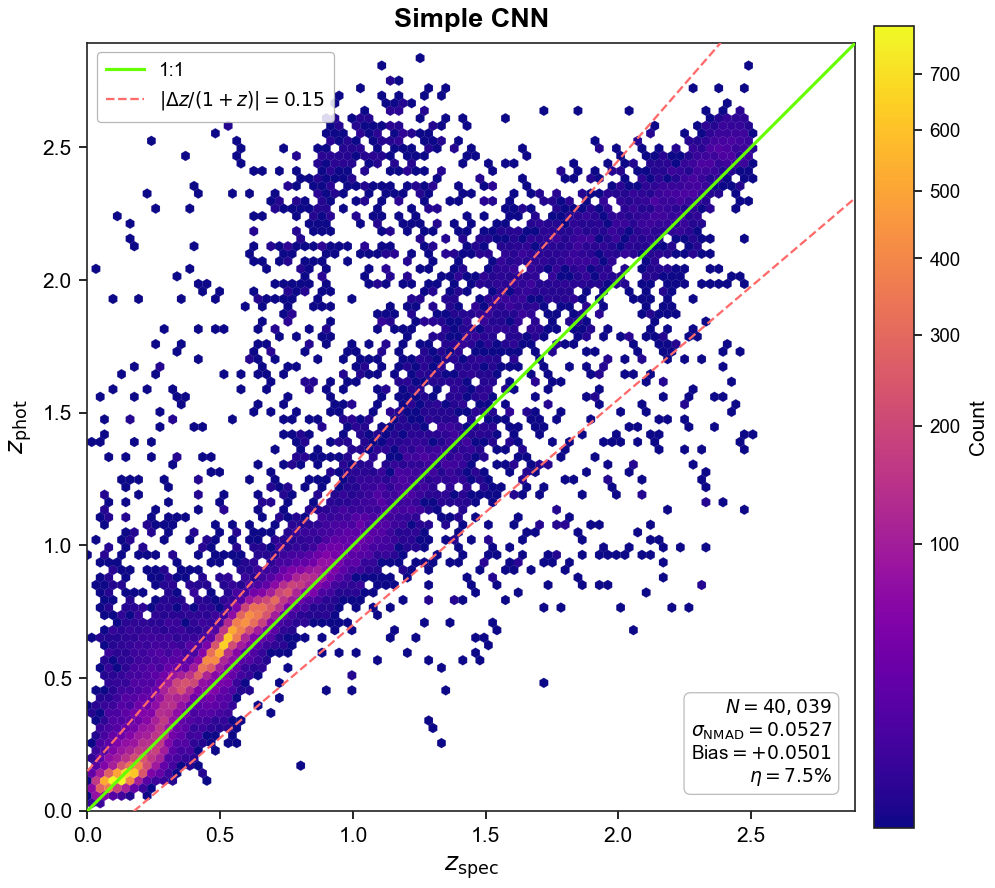

In [58]:
plot_pred_vs_true(
    y_test, y_pred_cnn,
    name="Simple CNN",
    save_path=os.path.join(BASE_REPORTS, "cnn_scatter.png"),
)

Binned performance saved → /Users/arpinejanunts/Desktop/Capstone/reports/cnn_binned.png


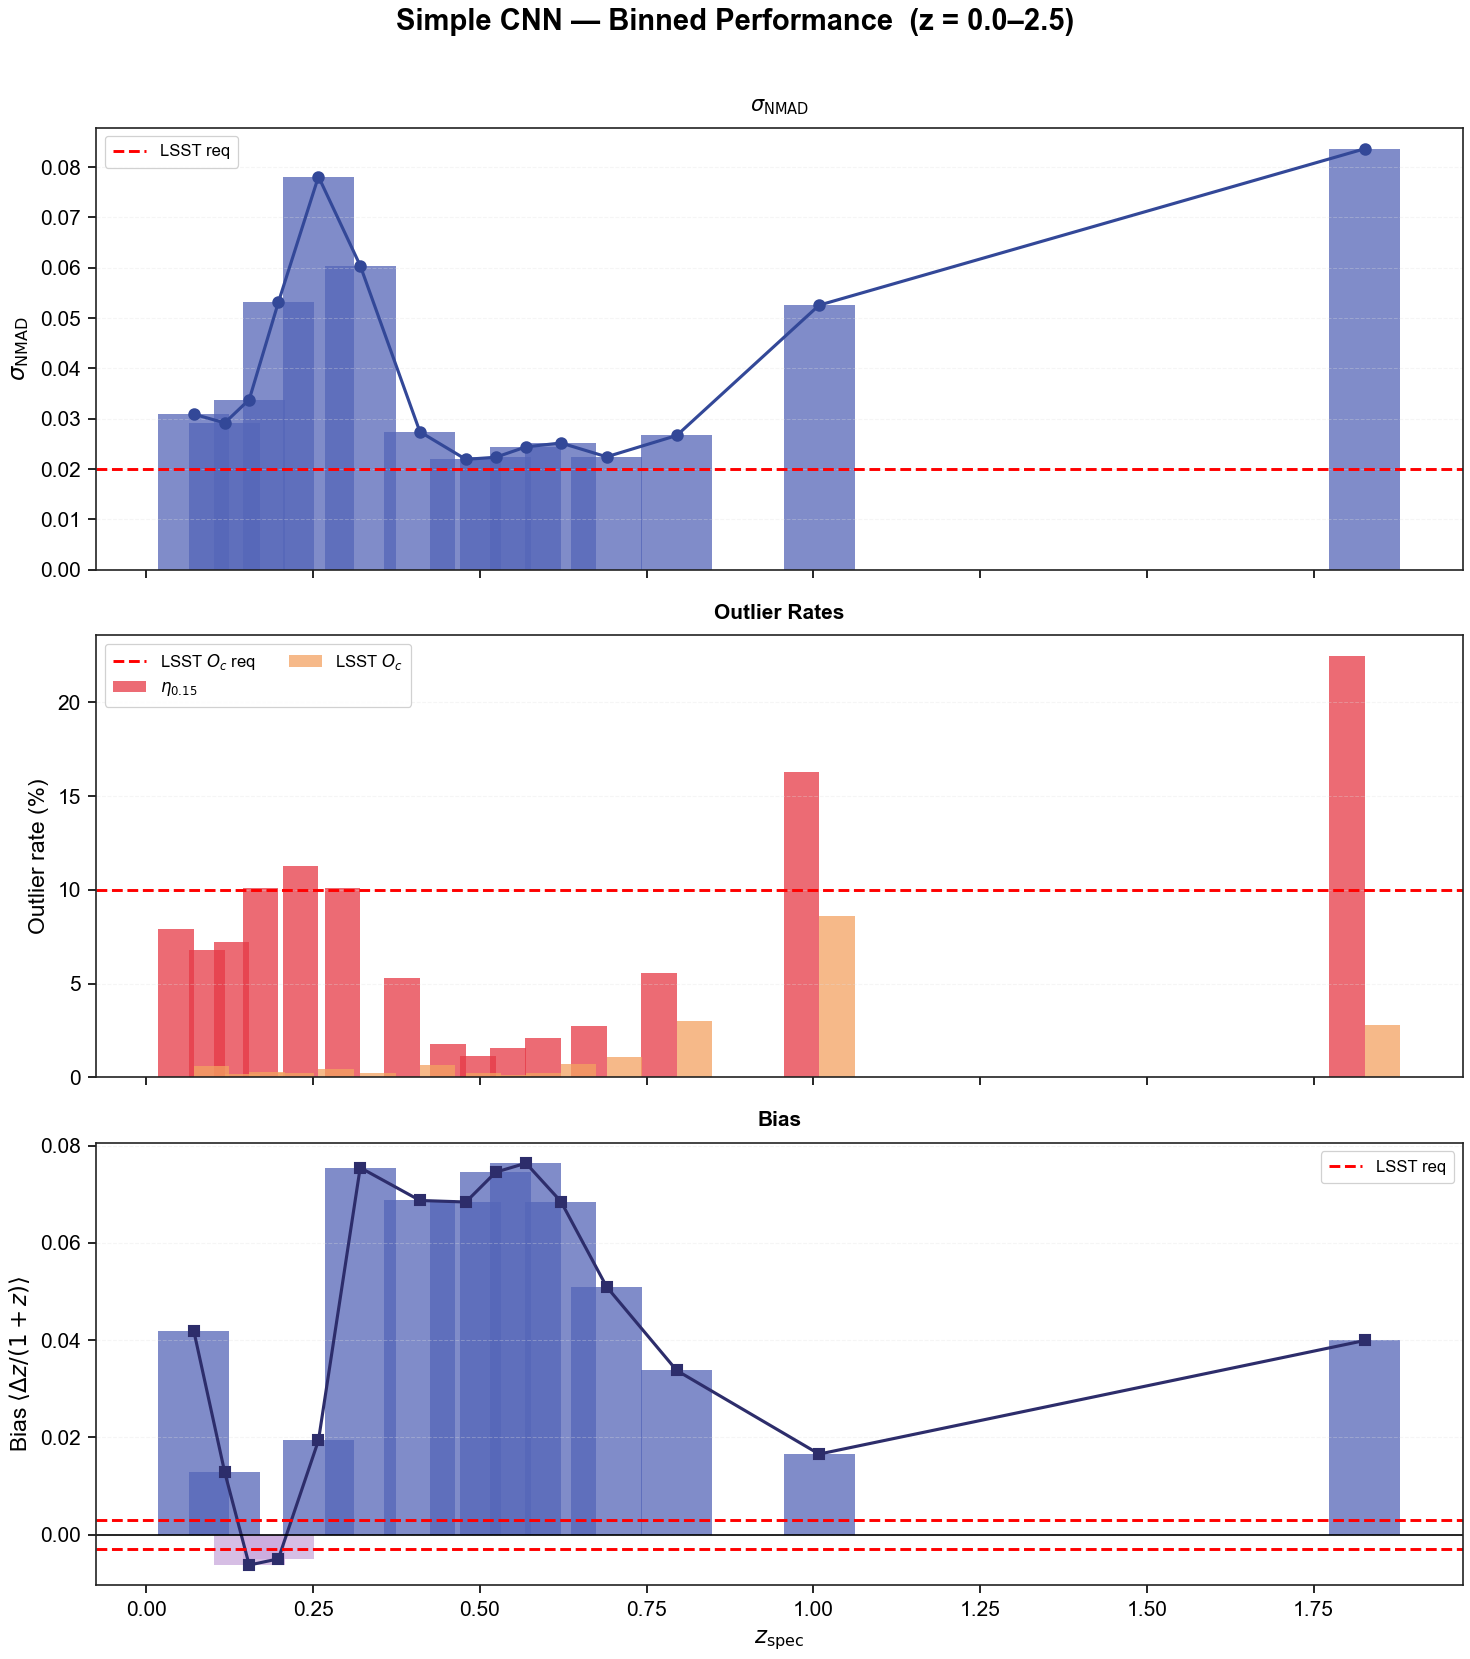

In [59]:
plot_binned_performance(
    y_test, y_pred_cnn,
    name="Simple CNN",
    n_bins=15,
    z_range=(0.0, 2.5),
    save_path=os.path.join(BASE_REPORTS, "cnn_binned.png"),
)

Full evaluation saved → /Users/arpinejanunts/Desktop/Capstone/reports/vgg16_full_eval.png


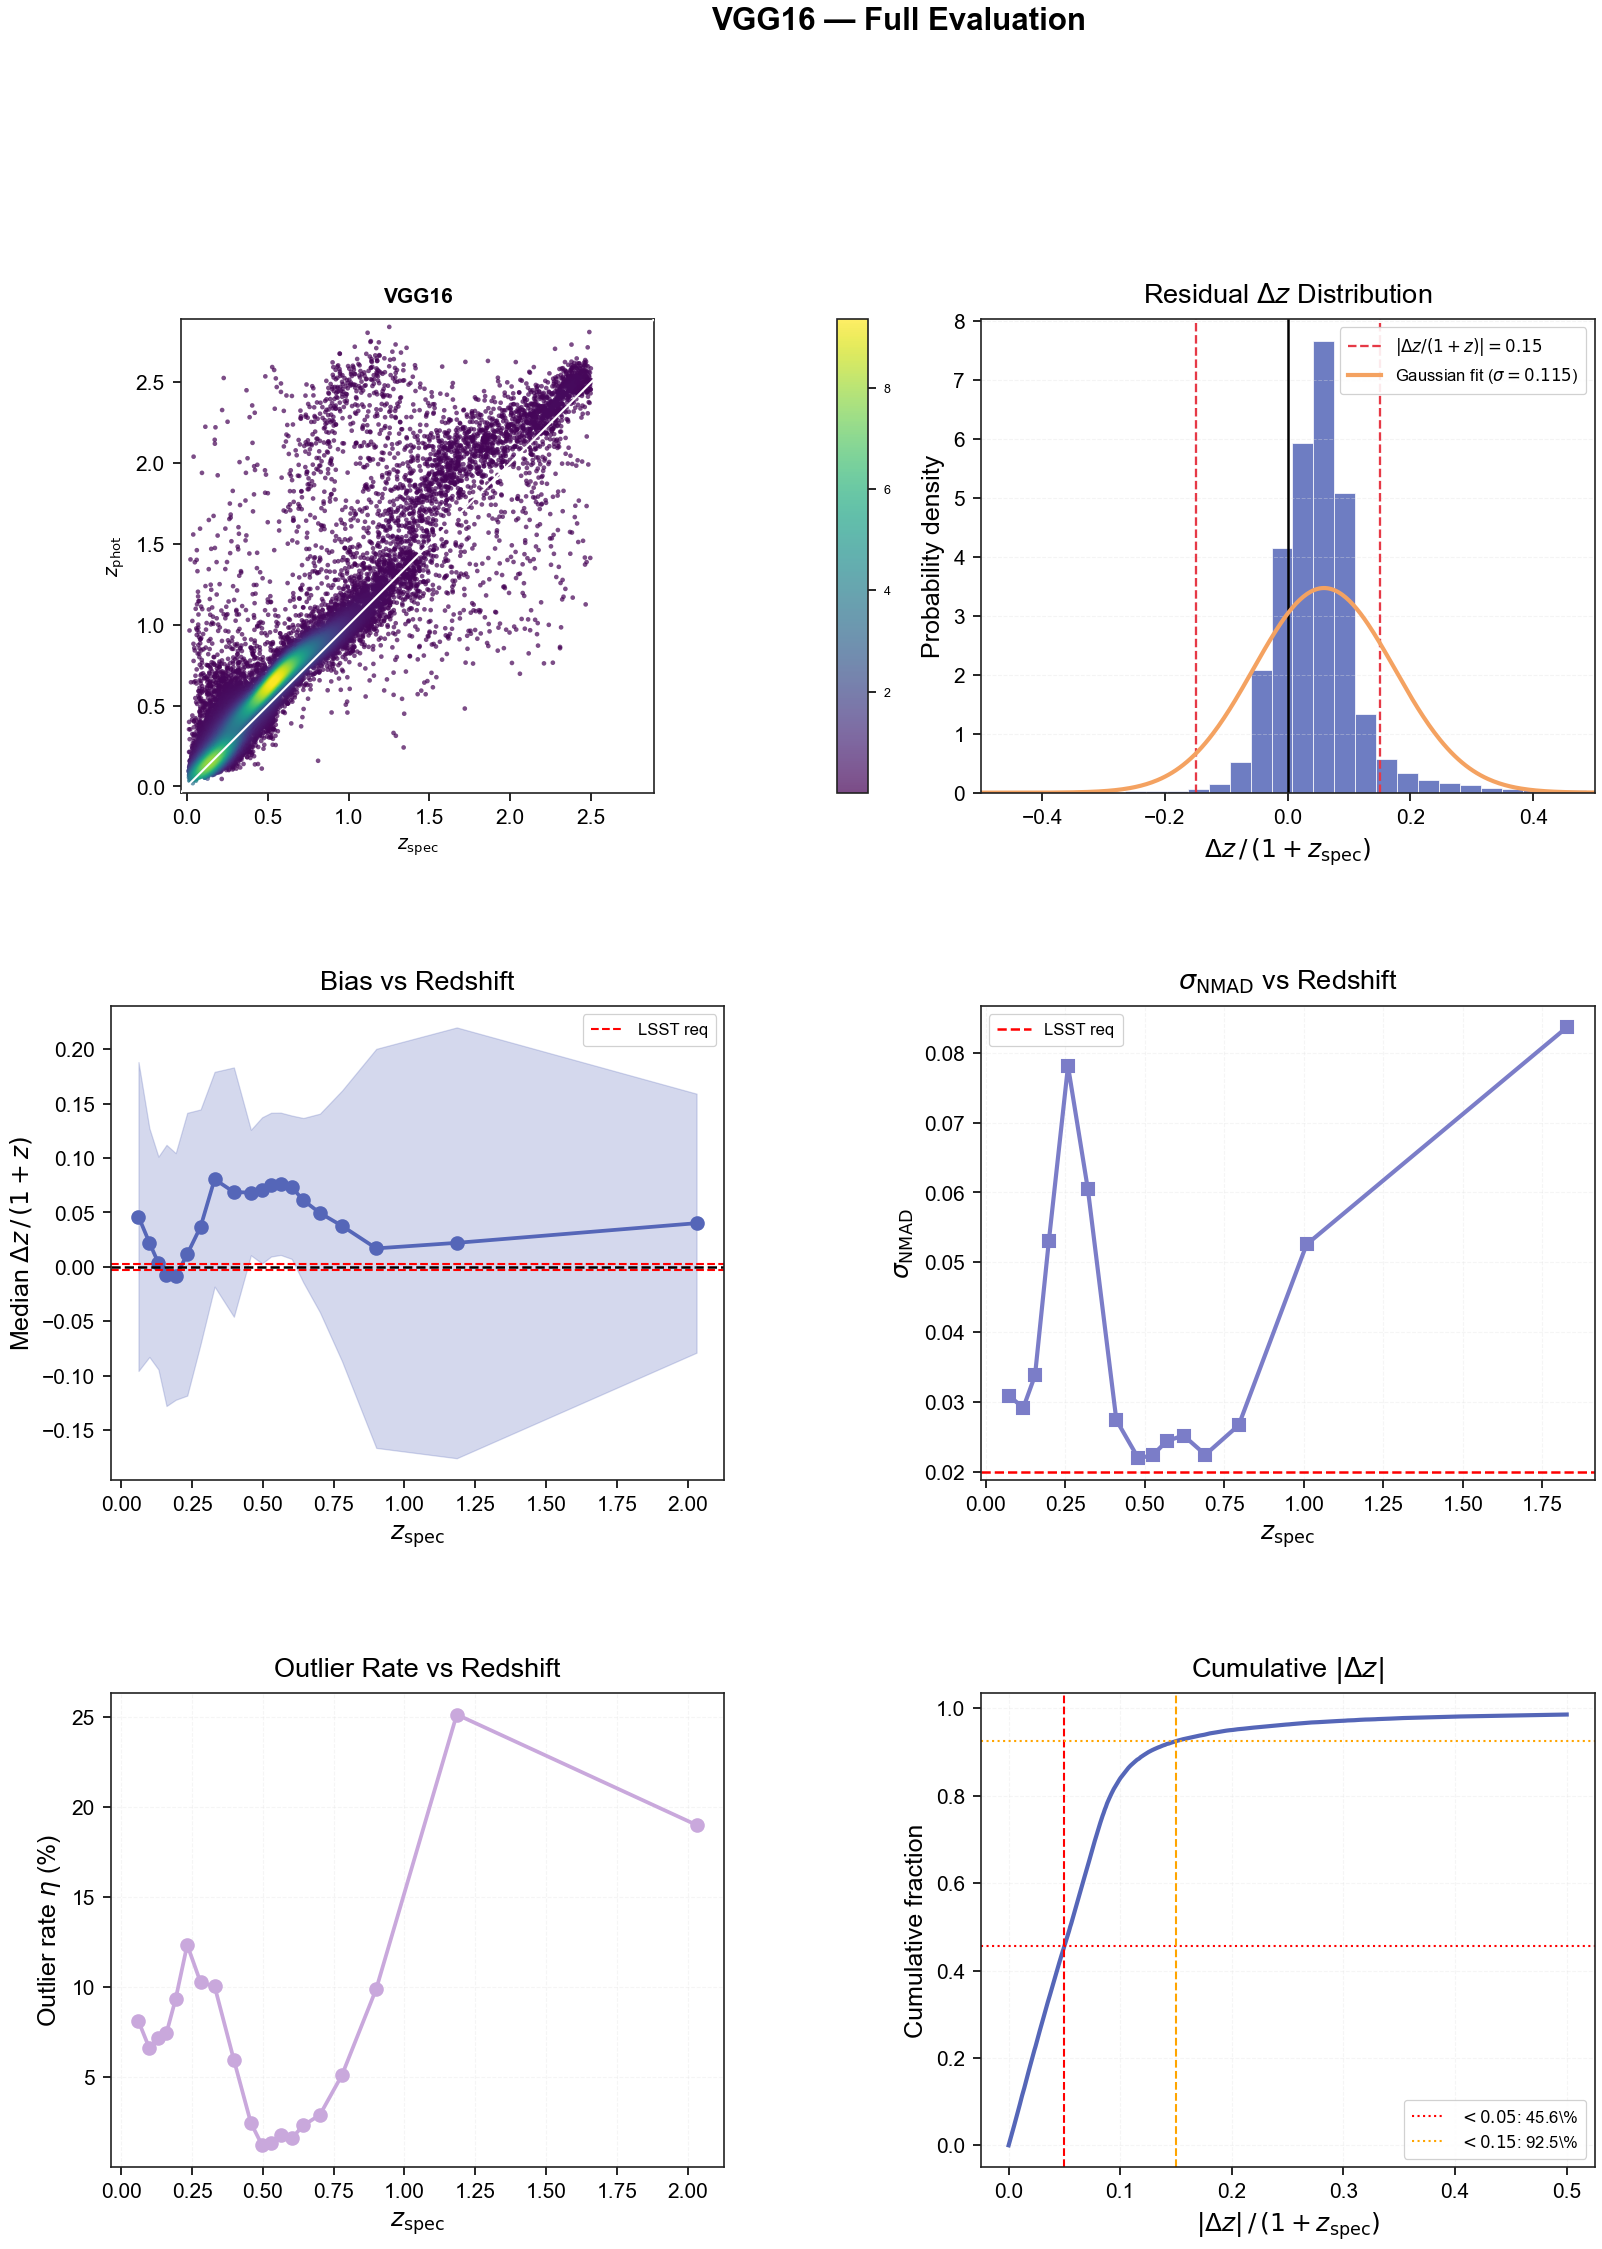

In [60]:
full_evaluation(
    name="VGG16",
    y_true=y_test,
    y_pred= y_pred_cnn,
    save_path=os.path.join(BASE_REPORTS, "vgg16_full_eval.png"),
)